**Title: Personalized Medical Recommendation System with Machine Learning**
### Description:
welcome to our cutting-edge Personalized Medical Recommendation System , a powerful platform designed to assit users in understanding and managing their health .
Leveraging the capabilies of machine learning our system analyzes user-input symptoms to predict potential diseases accurately

**Load dataset & tools**

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("dataset/Training (1).csv")


In [3]:
dataset.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [4]:
dataset.shape

(4920, 133)

In [5]:
dataset.isnull().sum()

itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
                       ..
inflammatory_nails      0
blister                 0
red_sore_around_nose    0
yellow_crust_ooze       0
prognosis               0
Length: 133, dtype: int64

In [6]:
len(dataset['prognosis'].unique())

41

In [8]:
dataset["prognosis"].unique().tolist()

['Fungal infection',
 'Allergy',
 'GERD',
 'Chronic cholestasis',
 'Drug Reaction',
 'Peptic ulcer diseae',
 'AIDS',
 'Diabetes ',
 'Gastroenteritis',
 'Bronchial Asthma',
 'Hypertension ',
 'Migraine',
 'Cervical spondylosis',
 'Paralysis (brain hemorrhage)',
 'Jaundice',
 'Malaria',
 'Chicken pox',
 'Dengue',
 'Typhoid',
 'hepatitis A',
 'Hepatitis B',
 'Hepatitis C',
 'Hepatitis D',
 'Hepatitis E',
 'Alcoholic hepatitis',
 'Tuberculosis',
 'Common Cold',
 'Pneumonia',
 'Dimorphic hemmorhoids(piles)',
 'Heart attack',
 'Varicose veins',
 'Hypothyroidism',
 'Hyperthyroidism',
 'Hypoglycemia',
 'Osteoarthristis',
 'Arthritis',
 '(vertigo) Paroymsal  Positional Vertigo',
 'Acne',
 'Urinary tract infection',
 'Psoriasis',
 'Impetigo']

In [30]:
dataset['prognosis'].value_counts()

prognosis
Fungal infection                           120
Hepatitis C                                120
Hepatitis E                                120
Alcoholic hepatitis                        120
Tuberculosis                               120
Common Cold                                120
Pneumonia                                  120
Dimorphic hemmorhoids(piles)               120
Heart attack                               120
Varicose veins                             120
Hypothyroidism                             120
Hyperthyroidism                            120
Hypoglycemia                               120
Osteoarthristis                            120
Arthritis                                  120
(vertigo) Paroymsal  Positional Vertigo    120
Acne                                       120
Urinary tract infection                    120
Psoriasis                                  120
Hepatitis D                                120
Hepatitis B                                120
All

## 📊 Step 3: Exploratory Data Analysis (EDA)
### Let's visualize disease distribution to understand data patterns

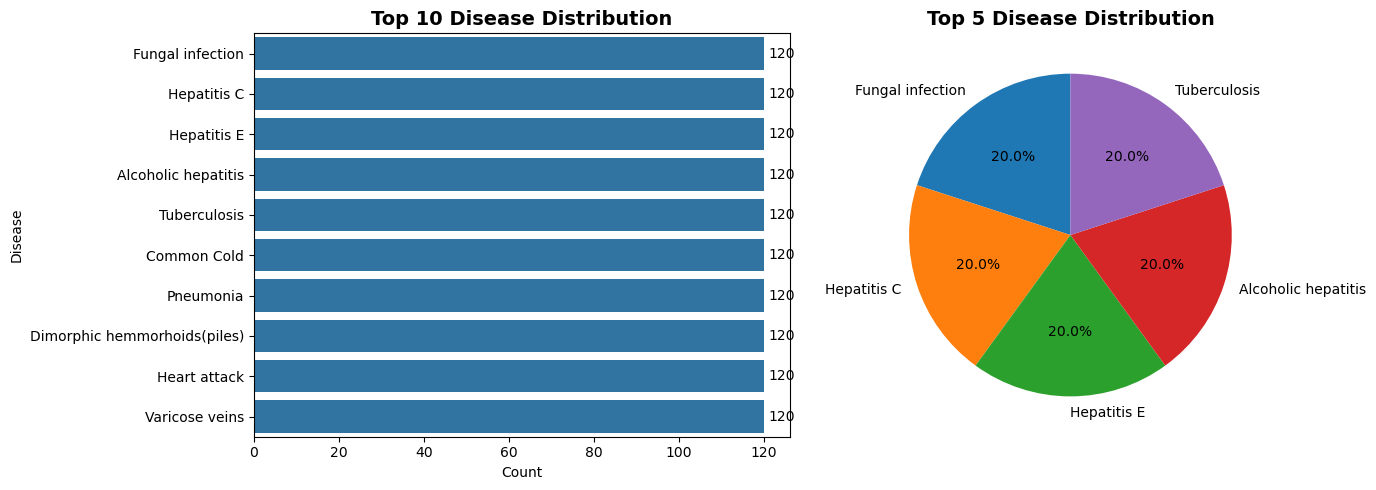

Total Unique Diseases: 41


In [31]:
# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# 🔹 Count Plot (Top 10 Diseases)
top_diseases = dataset['prognosis'].value_counts().head(10)

sns.barplot(x=top_diseases.values, y=top_diseases.index, ax=axes[0])
axes[0].set_title("Top 10 Disease Distribution", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Disease")

# Add values on bars
for i, v in enumerate(top_diseases.values):
    axes[0].text(v + 1, i, str(v), va='center')


# 🔹 Pie Chart (Top 5 Diseases)
top5 = dataset['prognosis'].value_counts().head(5)

axes[1].pie(top5.values,
            labels=top5.index,
            autopct='%1.1f%%',
            startangle=90)

axes[1].set_title("Top 5 Disease Distribution", fontsize=14, fontweight='bold')


plt.tight_layout()
plt.show()

# Print summary
print(f"Total Unique Diseases: {dataset['prognosis'].nunique()}")

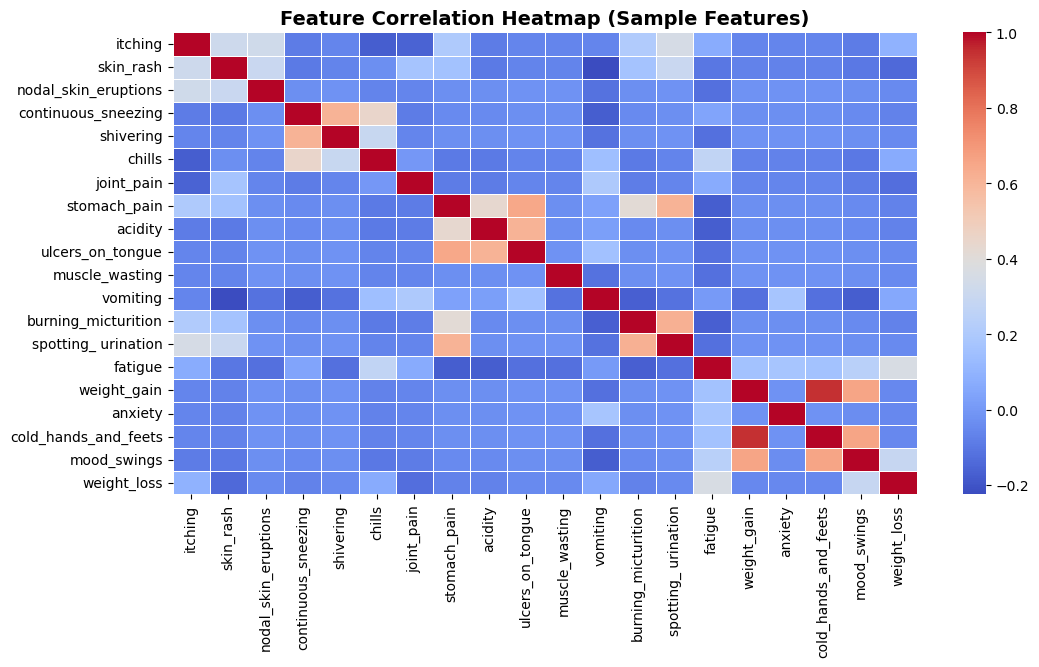

In [35]:
# 🔹 3.4 Correlation Analysis
# Let's visualize relationships between symptoms

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

# Using subset to avoid overcrowding
subset = dataset.iloc[:, :20]

sns.heatmap(subset.corr(),
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Feature Correlation Heatmap (Sample Features)", fontsize=14, fontweight='bold')

plt.show()

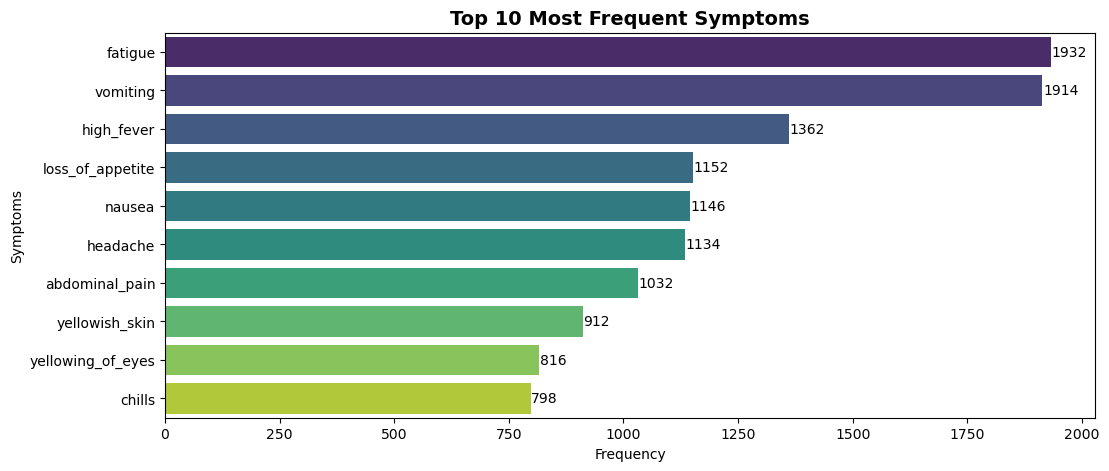

In [ ]:
symptom_counts = dataset.drop('prognosis', axis=1).sum().sort_values(ascending=False)

plt.figure(figsize=(12,5))

sns.barplot(x=symptom_counts.head(10).values,
            y=symptom_counts.head(10).index,
            palette='viridis')

plt.title("Top 10 Most Frequent Symptoms", fontsize=14, fontweight='bold')
plt.xlabel("Frequency")
plt.ylabel("Symptoms")

# Add value labels
for i, v in enumerate(symptom_counts.head(10).values):
    plt.text(v + 1, i, str(v), va='center')

plt.show()

# Train Test Split

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [10]:
x= dataset.drop("prognosis",axis=1)
y= dataset["prognosis"]

In [11]:
x.shape

(4920, 132)

In [12]:
le = LabelEncoder()
le.fit(y)
Y =le.transform(y)

In [13]:
Y

array([15, 15, 15, ..., 38, 35, 27])

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,Y,test_size=0.3,random_state=20)

In [15]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((3444, 132), (1476, 132), (3444,), (1476,))

## Training Top Model

In [16]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

#create a dictionary to store models
models = {
    "SVC": SVC(kernel='linear'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "KNeighbors": KNeighborsClassifier(n_neighbors=5),
    "MultinomialNB": MultinomialNB()
}
for model_name, model in models.items():
   
   # train model
   model.fit(x_train,y_train) 

   # test model
   predictions = model.predict(x_test)

   # calculating  accuracy
   accuracy = accuracy_score(y_test,predictions)

   # calculating confusion matrix
   cm  = confusion_matrix(y_test,predictions)

   print(f"{model_name} accuracy: {accuracy}")
   print(f"{model_name} Confusion Matrix:")
   print(np.array2string(cm, separator =','))
    
    

SVC accuracy: 1.0
SVC Confusion Matrix:
[[40, 0, 0,..., 0, 0, 0],
 [ 0,43, 0,..., 0, 0, 0],
 [ 0, 0,28,..., 0, 0, 0],
 ...,
 [ 0, 0, 0,...,34, 0, 0],
 [ 0, 0, 0,..., 0,41, 0],
 [ 0, 0, 0,..., 0, 0,31]]
Random Forest accuracy: 1.0
Random Forest Confusion Matrix:
[[40, 0, 0,..., 0, 0, 0],
 [ 0,43, 0,..., 0, 0, 0],
 [ 0, 0,28,..., 0, 0, 0],
 ...,
 [ 0, 0, 0,...,34, 0, 0],
 [ 0, 0, 0,..., 0,41, 0],
 [ 0, 0, 0,..., 0, 0,31]]
Gradient Boosting accuracy: 1.0
Gradient Boosting Confusion Matrix:
[[40, 0, 0,..., 0, 0, 0],
 [ 0,43, 0,..., 0, 0, 0],
 [ 0, 0,28,..., 0, 0, 0],
 ...,
 [ 0, 0, 0,...,34, 0, 0],
 [ 0, 0, 0,..., 0,41, 0],
 [ 0, 0, 0,..., 0, 0,31]]
KNeighbors accuracy: 1.0
KNeighbors Confusion Matrix:
[[40, 0, 0,..., 0, 0, 0],
 [ 0,43, 0,..., 0, 0, 0],
 [ 0, 0,28,..., 0, 0, 0],
 ...,
 [ 0, 0, 0,...,34, 0, 0],
 [ 0, 0, 0,..., 0,41, 0],
 [ 0, 0, 0,..., 0, 0,31]]
MultinomialNB accuracy: 1.0
MultinomialNB Confusion Matrix:
[[40, 0, 0,..., 0, 0, 0],
 [ 0,43, 0,..., 0, 0, 0],
 [ 0, 0,28,..., 0,

## Single prediction

In [17]:
svc =SVC(kernel='linear')
svc.fit(x_train,y_train)
ypred = svc.predict(x_test)
accuracy_score(y_test,ypred)

1.0

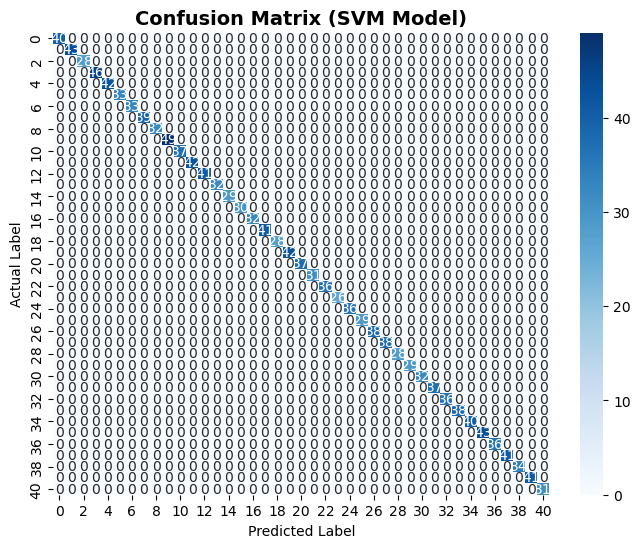

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, ypred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix (SVM Model)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [18]:
#saving the model 
import pickle
pickle.dump(svc,open("svc.pkl","wb"))

In [19]:
# load model

SVC = pickle.load(open("svc.pkl","rb"))

In [20]:
x_test.iloc[0].values

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

In [21]:
# test 1
print("Predicted Label : " , svc.predict(x_test.iloc[0].values.reshape(1,-1)))
print("Actual Label : ",y_test[0])

Predicted Label :  [40]
Actual Label :  40


In [22]:
# test 2
print("Predicted Label : " , svc.predict(x_test.iloc[20].values.reshape(1,-1)))
print("Actual Label : ",y_test[20])

Predicted Label :  [10]
Actual Label :  10


## Recommendation System and Prediction

**Load database and use logic for recommendation**

In [23]:
sym_des = pd.read_csv("dataset/symtoms_df.csv")
precautions = pd.read_csv("dataset/precautions_df.csv")
workout = pd.read_csv("dataset/workout_df.csv")
description = pd.read_csv("dataset/description.csv")
medications = pd.read_csv("dataset/medications.csv")
diets = pd.read_csv("dataset/diets.csv")

In [45]:

 # custome and helping functions
 #====================helper functions ================
def helper(dis):
    desc = description[description['Disease'] == dis]['Description']
    desc = " ".join([w for w in desc])
    
    pre = precautions[precautions['Disease'] == dis][['Precaution_1' , 'Precaution_2', 'Precaution_3', 'Precaution_4']]
    pre = [col for col in pre.values]
    
    med = medications[medications['Disease'] == dis]['Medication']
    med = [med for med in med.values]
    
    die = diets[diets['Disease'] == dis]['Diet']
    die = [d for d in die.values]
    
    wrkout = workout[workout['disease'] == dis]['workout']
    
    return desc, pre, med, die, wrkout       
           
           
           
symptoms_dict = {'itching': 0, 'skin_rash': 1, 'nodal_skin_eruptions': 2, 'continuous_sneezing': 3, 'shivering': 4, 'chills': 5, 'joint_pain': 6, 'stomach_pain': 7, 'acidity': 8, 'ulcers_on_tongue': 9, 'muscle_wasting': 10, 'vomiting': 11, 'burning_micturition': 12, 'spotting_ urination': 13, 'fatigue': 14, 'weight_gain': 15, 'anxiety': 16, 'cold_hands_and_feets': 17, 'mood_swings': 18, 'weight_loss': 19, 'restlessness': 20, 'lethargy': 21, 'patches_in_throat': 22, 'irregular_sugar_level': 23, 'cough': 24, 'high_fever': 25, 'sunken_eyes': 26, 'breathlessness': 27, 'sweating': 28, 'dehydration': 29, 'indigestion': 30, 'headache': 31, 'yellowish_skin': 32, 'dark_urine': 33, 'nausea': 34, 'loss_of_appetite': 35, 'pain_behind_the_eyes': 36, 'back_pain': 37, 'constipation': 38, 'abdominal_pain': 39, 'diarrhoea': 40, 'mild_fever': 41, 'yellow_urine': 42, 'yellowing_of_eyes': 43, 'acute_liver_failure': 44, 'fluid_overload': 45, 'swelling_of_stomach': 46, 'swelled_lymph_nodes': 47, 'malaise': 48, 'blurred_and_distorted_vision': 49, 'phlegm': 50, 'throat_irritation': 51, 'redness_of_eyes': 52, 'sinus_pressure': 53, 'runny_nose': 54, 'congestion': 55, 'chest_pain': 56, 'weakness_in_limbs': 57, 'fast_heart_rate': 58, 'pain_during_bowel_movements': 59, 'pain_in_anal_region': 60, 'bloody_stool': 61, 'irritation_in_anus': 62, 'neck_pain': 63, 'dizziness': 64, 'cramps': 65, 'bruising': 66, 'obesity': 67, 'swollen_legs': 68, 'swollen_blood_vessels': 69, 'puffy_face_and_eyes': 70, 'enlarged_thyroid': 71, 'brittle_nails': 72, 'swollen_extremeties': 73, 'excessive_hunger': 74, 'extra_marital_contacts': 75, 'drying_and_tingling_lips': 76, 'slurred_speech': 77, 'knee_pain': 78, 'hip_joint_pain': 79, 'muscle_weakness': 80, 'stiff_neck': 81, 'swelling_joints': 82, 'movement_stiffness': 83, 'spinning_movements': 84, 'loss_of_balance': 85, 'unsteadiness': 86, 'weakness_of_one_body_side': 87, 'loss_of_smell': 88, 'bladder_discomfort': 89, 'foul_smell_of urine': 90, 'continuous_feel_of_urine': 91, 'passage_of_gases': 92, 'internal_itching': 93, 'toxic_look_(typhos)': 94, 'depression': 95, 'irritability': 96, 'muscle_pain': 97, 'altered_sensorium': 98, 'red_spots_over_body': 99, 'belly_pain': 100, 'abnormal_menstruation': 101, 'dischromic _patches': 102, 'watering_from_eyes': 103, 'increased_appetite': 104, 'polyuria': 105, 'family_history': 106, 'mucoid_sputum': 107, 'rusty_sputum': 108, 'lack_of_concentration': 109, 'visual_disturbances': 110, 'receiving_blood_transfusion': 111, 'receiving_unsterile_injections': 112, 'coma': 113, 'stomach_bleeding': 114, 'distention_of_abdomen': 115, 'history_of_alcohol_consumption': 116, 'fluid_overload.1': 117, 'blood_in_sputum': 118, 'prominent_veins_on_calf': 119, 'palpitations': 120, 'painful_walking': 121, 'pus_filled_pimples': 122, 'blackheads': 123, 'scurring': 124, 'skin_peeling': 125, 'silver_like_dusting': 126, 'small_dents_in_nails': 127, 'inflammatory_nails': 128, 'blister': 129, 'red_sore_around_nose': 130, 'yellow_crust_ooze': 131}
diseases_list = {15: 'Fungal infection', 4: 'Allergy', 16: 'GERD', 9: 'Chronic cholestasis', 14: 'Drug Reaction', 33: 'Peptic ulcer diseae', 1: 'AIDS', 12: 'Diabetes ', 17: 'Gastroenteritis', 6: 'Bronchial Asthma', 23: 'Hypertension ', 30: 'Migraine', 7: 'Cervical spondylosis', 32: 'Paralysis (brain hemorrhage)', 28: 'Jaundice', 29: 'Malaria', 8: 'Chicken pox', 11: 'Dengue', 37: 'Typhoid', 40: 'hepatitis A', 19: 'Hepatitis B', 20: 'Hepatitis C', 21: 'Hepatitis D', 22: 'Hepatitis E', 3: 'Alcoholic hepatitis', 36: 'Tuberculosis', 10: 'Common Cold', 34: 'Pneumonia', 13: 'Dimorphic hemmorhoids(piles)', 18: 'Heart attack', 39: 'Varicose veins', 26: 'Hypothyroidism', 24: 'Hyperthyroidism', 25: 'Hypoglycemia', 31: 'Osteoarthristis', 5: 'Arthritis', 0: '(vertigo) Paroymsal  Positional Vertigo', 2: 'Acne', 38: 'Urinary tract infection', 35: 'Psoriasis', 27: 'Impetigo'}

# model prediction function
def get_predicted_value(patient_symptoms):
    input_vector = np.zeros(len(symptoms_dict))
    
    for item in patient_symptoms:
        input_vector[symptoms_dict[item]] = 1
    
    return diseases_list[svc.predict([input_vector])[0]]

In [43]:
# Test 1
# Split the user's input into a list of symptoms (assuming they are comma-separated) # yellow_crust_ooze,red_sore_around_nose,small_dents_in_nails,inflammatory_nails,blister
symptoms = input("Enter your symptoms.......")
user_symptoms = [s.strip() for s in symptoms.split(',')]
# Remove any extra characters, if any
user_symptoms = [symptom.strip("[]' ") for symptom in user_symptoms]
predicted_disease = get_predicted_value(user_symptoms)

desc, pre, med, die, wrkout = helper(predicted_disease)


In [46]:
# results print

print("=====================Predicted Disease=====================")
print(predicted_disease)
print("=====================Description=====================")
print(desc)
print("=====================Precautions=====================")
i = 1
for p_i in pre[0]:
    print(i,":", p_i)
    i+=1
print("=====================Medication=====================")
i = 1
for m_i in med:
    print(i,": ", m_i)
    i+=1

print("=====================Diet=====================")
i = 1
for d_i in die:
    print(i,": ", d_i)
    i+=1    

print("=====================Workout=====================")
i = 1
for w_i in wrkout:
    print(i,": ", w_i)
    i+=1    

=====================Predicted Disease=====================
AIDS
=====================Description=====================
AIDS (Acquired Immunodeficiency Syndrome) is a disease caused by HIV that weakens the immune system.
=====================Precautions=====================
1 : avoid open cuts
2 : wear ppe if possible
3 : consult doctor
4 : follow up
=====================Medication=====================
1 :  ['Antiretroviral drugs', 'Protease inhibitors', 'Integrase inhibitors', 'Entry inhibitors', 'Fusion inhibitors']
=====================Diet=====================
1 :  ['Balanced Diet', 'Protein-rich foods', 'Fruits and vegetables', 'Whole grains', 'Healthy fats']
=====================Workout=====================
1 :  Follow a balanced and nutritious diet
2 :  Include lean proteins
3 :  Consume nutrient-rich foods
4 :  Stay hydrated
5 :  Include healthy fats
6 :  Avoid raw or undercooked foods
7 :  Limit sugary foods and beverages
8 :  Consume immune-boosting foods
9 :  Take prescribed 

In [ ]:
import sklearn
print(sklearn.__version__)

1.5.1
